# Chapter 107 — Parametric Curves

> **Prerequisites:** ch106 (Polar), ch095 (Interpolation)
>
> **Outcomes:** Describe curves as (x(t), y(t)) pairs; Compute arc length and tangent vectors; Plot Lissajous and cycloid curves


## What Is a Parametric Curve?

A **parametric curve** describes a path in 2D as a function of a parameter t:
x = x(t), y = y(t)

This separates **position** from **shape**. The parameter t is often time.

Examples:
- Circle: x = cos(t), y = sin(t), t ∈ [0, 2π]
- Ellipse: x = a·cos(t), y = b·sin(t)
- Cycloid: x = r(t - sin t), y = r(1 - cos t)  — path traced by point on rolling circle
- Helix: x = cos(t), y = sin(t), z = t/2π  — spiral in 3D

**Tangent vector:** (dx/dt, dy/dt) — the instantaneous direction of motion
**Arc length:** L = ∫||(dx/dt, dy/dt)|| dt = ∫√((dx/dt)² + (dy/dt)²) dt

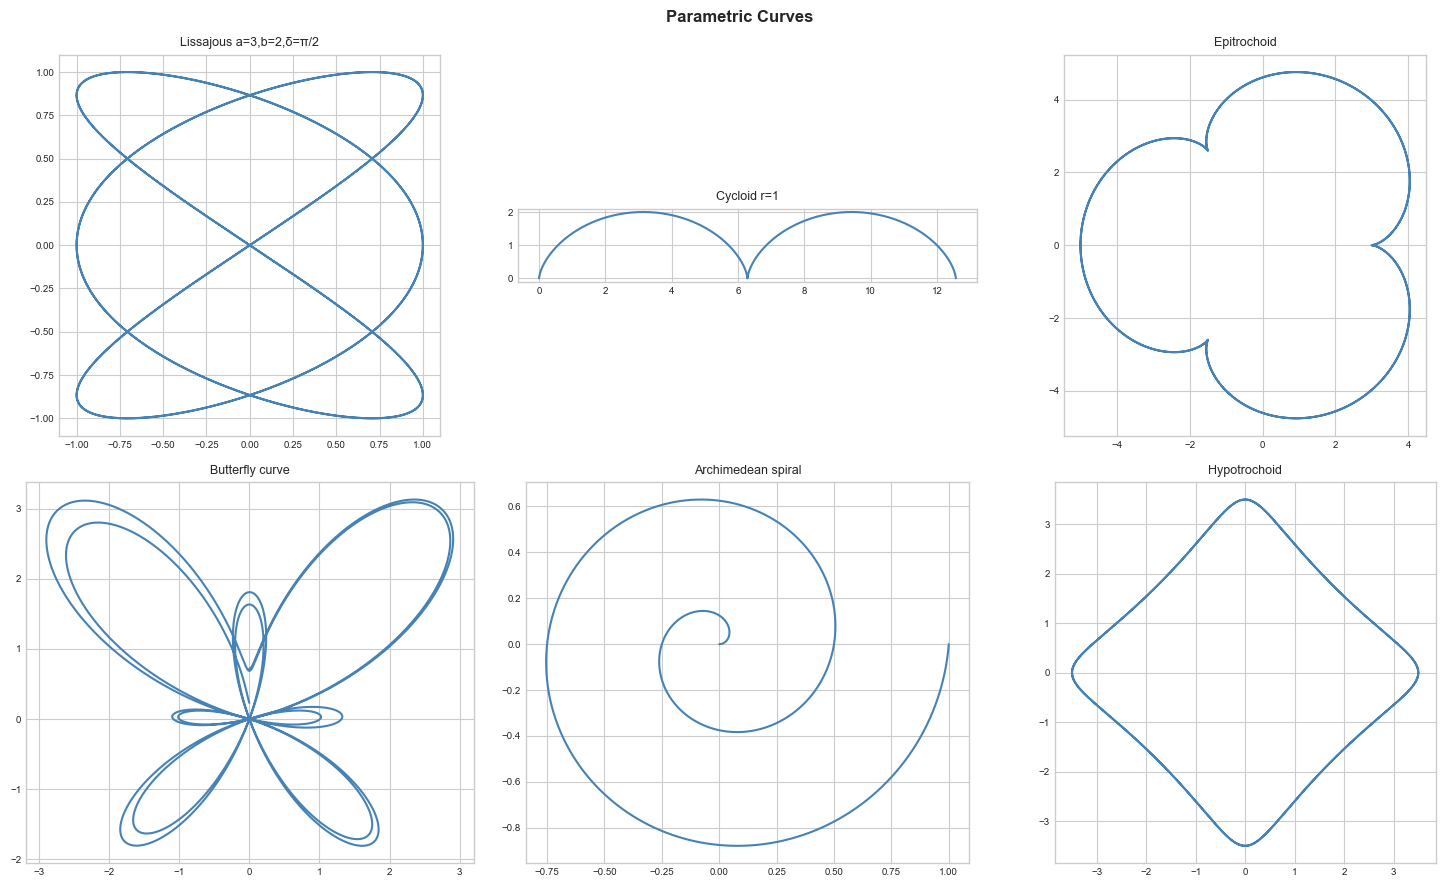

In [1]:
# --- Parametric curves ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

t = np.linspace(0, 4*np.pi, 2000)
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

curves = [
    ('Lissajous a=3,b=2,δ=π/2', lambda t: (np.sin(3*t+np.pi/2), np.sin(2*t))),
    ('Cycloid r=1', lambda t: (t - np.sin(t), 1 - np.cos(t))),
    ('Epitrochoid', lambda t: ((3+1)*np.cos(t) - 1*np.cos((3+1)*t),
                               (3+1)*np.sin(t) - 1*np.sin((3+1)*t))),
    ('Butterfly curve', lambda t: (np.sin(t)*(np.exp(np.cos(t))-2*np.cos(4*t)-np.sin(t/12)**5),
                                   np.cos(t)*(np.exp(np.cos(t))-2*np.cos(4*t)-np.sin(t/12)**5))),
    ('Archimedean spiral', lambda t: (t/(4*np.pi)*np.cos(t), t/(4*np.pi)*np.sin(t))),
    ('Hypotrochoid', lambda t: ((4-1)*np.cos(t)+0.5*np.cos((4-1)*t),
                                (4-1)*np.sin(t)-0.5*np.sin((4-1)*t))),
]

for ax, (name, curve_fn) in zip(axes.flat, curves):
    x, y = curve_fn(t)
    ax.plot(x, y, color='steelblue', lw=1.5)
    ax.set_aspect('equal'); ax.set_title(name, fontsize=9)
    ax.tick_params(labelsize=7)

plt.suptitle('Parametric Curves', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

## Arc Length and Tangent



Cycloid arc length (one arch): 7.9999
Exact: 8r = 8.0000


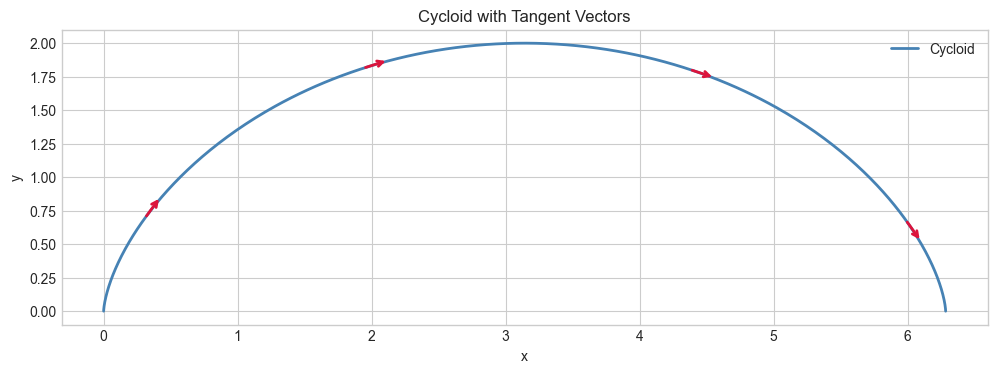

In [3]:
# --- Numerical arc length and tangent vectors ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

# Cycloid
t = np.linspace(0, 2*np.pi, 500)
r = 1
x = r*(t - np.sin(t))
y = r*(1 - np.cos(t))

# Numerical derivatives
dx = np.gradient(x, t)
dy = np.gradient(y, t)
speed = np.sqrt(dx**2 + dy**2)

# Arc length by numerical integration
arc_length = np.trapezoid(speed, t)
print(f"Cycloid arc length (one arch): {arc_length:.4f}")
print(f"Exact: 8r = {8*r:.4f}")  # known result

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(x, y, 'steelblue', lw=2, label='Cycloid')
# Show tangent vectors at several points
indices = [100, 200, 300, 400]
for i in indices:
    ax.annotate('', (x[i]+0.2*dx[i]/speed[i], y[i]+0.2*dy[i]/speed[i]),
                (x[i], y[i]), arrowprops=dict(arrowstyle='->', color='crimson', lw=2))
ax.set_aspect('equal'); ax.set_title('Cycloid with Tangent Vectors')
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.legend()
plt.tight_layout(); plt.show()

## Summary

- Parametric: (x(t), y(t)) traces any curve — not limited to functions y=f(x)
- Tangent = (dx/dt, dy/dt); arc length = ∫√(ẋ²+ẏ²)dt
- Enables curves with loops, cusps, spirals that would fail the vertical line test

**Forward:** ch116 (Bézier Curves) uses parametric representation; ch120 (Physics Simulator) uses parametric motion.